In [2]:
import numpy as np
import torch
import torchvision.models
import torch.nn as nn
import pandas as pd
import time
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent.parent))
from models.utils import set_seed, train, evaluate_model, plot_training_history, get_loaders
from models.baseline_cnn import BaselineCNN
from models.alexnet import ModifiedAlexNet

sys.path.append(str(Path().resolve().parent))
# from hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison
sys.path.append(str(Path().resolve().parent.parent))
from utils import save_results

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: mps


In [3]:
from hyperparameters.hyperparameter_plots import summarize_results, print_summary_table, plot_loss_comparison, plot_accuracy_comparison

In [4]:
DATA_DIR = Path("../../data")

TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

In [5]:
ADVANCED_AUGMENTATIONS_CONFIGS = {
    "none": {
        "loader_aug": "none",
        "advanced_aug": None,
        "alpha": 0.4,
    },
    "cutout": {
        "loader_aug": "cutout",
        "advanced_aug": None,
        "alpha": 0.4,
    },
    "mixup": {
        "loader_aug": "none",
        "advanced_aug": "mixup",
        "alpha": 0.4,
    },
    "cutmix": {
        "loader_aug": "none",
        "advanced_aug": "cutmix",
        "alpha": 1.0,
    },
}
SEEDS = [0, 1, 2]
BATCH_SIZE = 256

In [6]:
def create_baseline_model():
    model = BaselineCNN(
        input_channels=3,
        image_size=32,
        conv_channels=[64, 128, 256],
        kernel_sizes=[3, 3, 3],
        fc_layers=[128, 64],
        num_classes=10,
    ).to(device)

    return model

def create_resnet_model():
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)
    return model

def create_alexnet_model():
    model = ModifiedAlexNet(num_classes=10).to(device)
    return model

def test_advanced_augmentation(
    model,
    augmentation_configs,
    seeds,
    scheduler=None,
    device=None,
    num_epochs=20,
):
    results = {}
    for aug_name, config in augmentation_configs.items():
        results[aug_name] = {}

        loader_aug = config["loader_aug"]
        advanced_aug = config["advanced_aug"]
        alpha = config.get("alpha", 0.4)

        for seed in seeds:
            print(f"\nAUGMENTATION NAME={aug_name} | SEED={seed}")
            set_seed(seed)

            train_loader, valid_loader, test_loader = get_loaders(
                train_dir=TRAIN_DIR,
                valid_dir=VALID_DIR,
                test_dir=TEST_DIR,
                image_size=32,
                batch_size=BATCH_SIZE,
                seed=seed,
                augmentation=loader_aug,
            )

            model_instance = model()
            criterion = torch.nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model_instance.parameters(), lr=1e-3)

            print("------------------------------------------------------")

            history = train(
                model_instance, 
                train_loader, 
                valid_loader, 
                criterion, 
                optimizer,
                scheduler=scheduler, 
                device=device, 
                num_epochs=num_epochs, 
                verbose=True, 
                verbose_interval=max(1, int(num_epochs/10)),
                advanced_aug=advanced_aug,
                alpha=alpha,
            )

            validation_accuracy = history['valid_acc'][-1]
            validation_loss = history['valid_loss'][-1]
            test_accuracy, test_loss = evaluate_model(
                model_instance, test_loader, criterion, device
            )

            results[aug_name][seed] = {
                "history": history,
                "valid_acc": validation_accuracy,
                "valid_loss": validation_loss,
                "test_acc": test_accuracy,
                "test_loss": test_loss,
                "loader_aug": loader_aug,
                "advanced_aug": advanced_aug,
                "alpha": alpha,
            }

            print("------------------------------------------------------")

            print(f"VALIDATION ACCURACY: {validation_accuracy:.4f} | TEST ACCURACY: {test_accuracy:.4f}")

            print("------------------------------------------------------")
    
    return results

## Advanced data augmentation experiments

#### Baseline model

In [7]:
baseline_adv_aug_results = test_advanced_augmentation(
    model=create_baseline_model,
    augmentation_configs=ADVANCED_AUGMENTATIONS_CONFIGS,
    seeds=SEEDS,
    device=device,
    num_epochs=20,
)


AUGMENTATION NAME=none | SEED=0
------------------------------------------------------
Epoch 2/20 | Train Loss: 1.2613 | Valid Loss: 1.4840 | Valid Acc: 0.4810
Epoch 4/20 | Train Loss: 1.0694 | Valid Loss: 1.1444 | Valid Acc: 0.5825
Epoch 6/20 | Train Loss: 0.9451 | Valid Loss: 1.0198 | Valid Acc: 0.6339
Epoch 8/20 | Train Loss: 0.8434 | Valid Loss: 1.3009 | Valid Acc: 0.5657
Epoch 10/20 | Train Loss: 0.7535 | Valid Loss: 0.9716 | Valid Acc: 0.6622
Epoch 12/20 | Train Loss: 0.6707 | Valid Loss: 1.6216 | Valid Acc: 0.5286
Epoch 14/20 | Train Loss: 0.5843 | Valid Loss: 1.0494 | Valid Acc: 0.6533
Epoch 16/20 | Train Loss: 0.5017 | Valid Loss: 1.6413 | Valid Acc: 0.5512
Epoch 18/20 | Train Loss: 0.4296 | Valid Loss: 1.2207 | Valid Acc: 0.6544
Epoch 20/20 | Train Loss: 0.3521 | Valid Loss: 2.3406 | Valid Acc: 0.4997
Best validation accuracy: 0.6622
------------------------------------------------------
VALIDATION ACCURACY: 0.4997 | TEST ACCURACY: 0.4977
------------------------------------

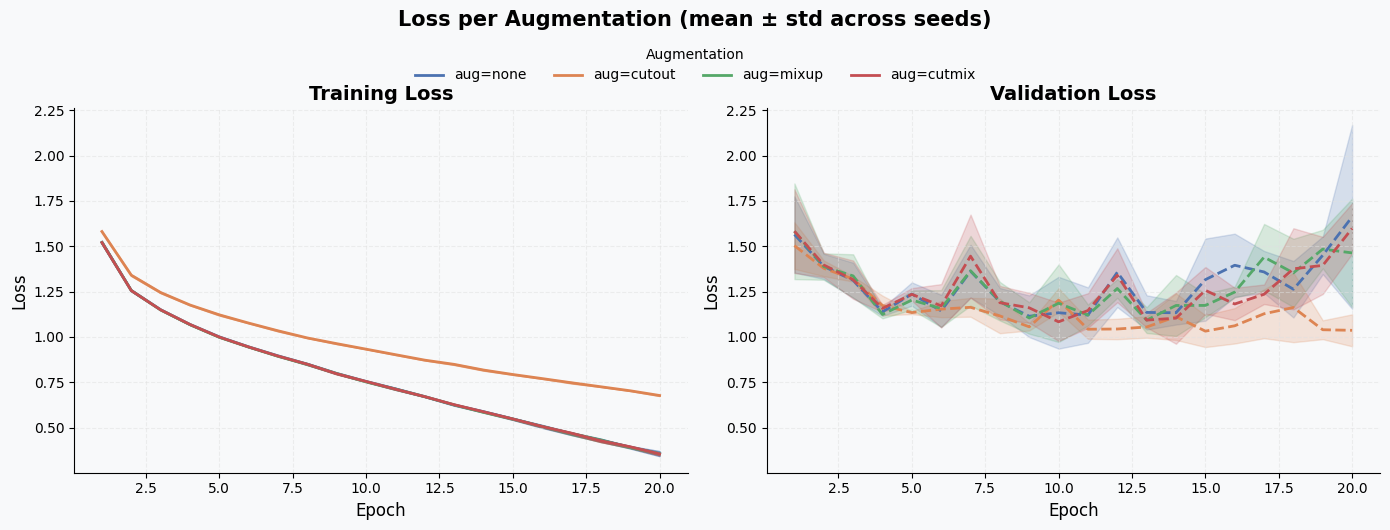

In [8]:
plot_loss_comparison(baseline_adv_aug_results, param_name="Augmentation", param_name_short="aug")

In [9]:
for aug, seed_dict in baseline_adv_aug_results.items():
    train_losses = np.array([seed_dict[s]['history']['train_loss'] for s in seed_dict])
    print(f"augmentation={aug} | seeds={train_losses.shape[0]} | max std={train_losses.std(axis=0).max():.6f}")

augmentation=none | seeds=3 | max std=0.013953
augmentation=cutout | seeds=3 | max std=0.004435
augmentation=mixup | seeds=3 | max std=0.009363
augmentation=cutmix | seeds=3 | max std=0.007696


In [10]:
baseline_adv_aug_df = summarize_results(
    baseline_adv_aug_results,
    hyperparameter="aug"
)
baseline_adv_aug_df

,Model,aug,Valid Acc Mean,Valid Acc Std,Valid Loss Mean,Valid Loss Std,Test Acc Mean,Test Acc Std,Test Loss Mean,Test Loss Std
0,Model,none,0.589919,0.069634,1.662065,0.506944,0.588333,0.069374,1.680454,0.512219
1,Model,cutout,0.660141,0.017583,1.036258,0.088193,0.656607,0.017163,1.046491,0.087276
2,Model,mixup,0.618481,0.037488,1.463155,0.299146,0.617022,0.038919,1.477576,0.306703
3,Model,cutmix,0.599567,0.017723,1.598068,0.139100,0.599615,0.019119,1.609929,0.148319


In [11]:
print_summary_table(baseline_adv_aug_df, hyperparameter="aug")

,Model,aug,Valid Acc,Valid Loss,Test Acc,Test Loss
0,Model,none,0.5899 ± 0.0696,1.6621 ± 0.5069,0.5883 ± 0.0694,1.6805 ± 0.5122
1,Model,cutout,0.6601 ± 0.0176,1.0363 ± 0.0882,0.6566 ± 0.0172,1.0465 ± 0.0873
2,Model,mixup,0.6185 ± 0.0375,1.4632 ± 0.2991,0.6170 ± 0.0389,1.4776 ± 0.3067
3,Model,cutmix,0.5996 ± 0.0177,1.5981 ± 0.1391,0.5996 ± 0.0191,1.6099 ± 0.1483


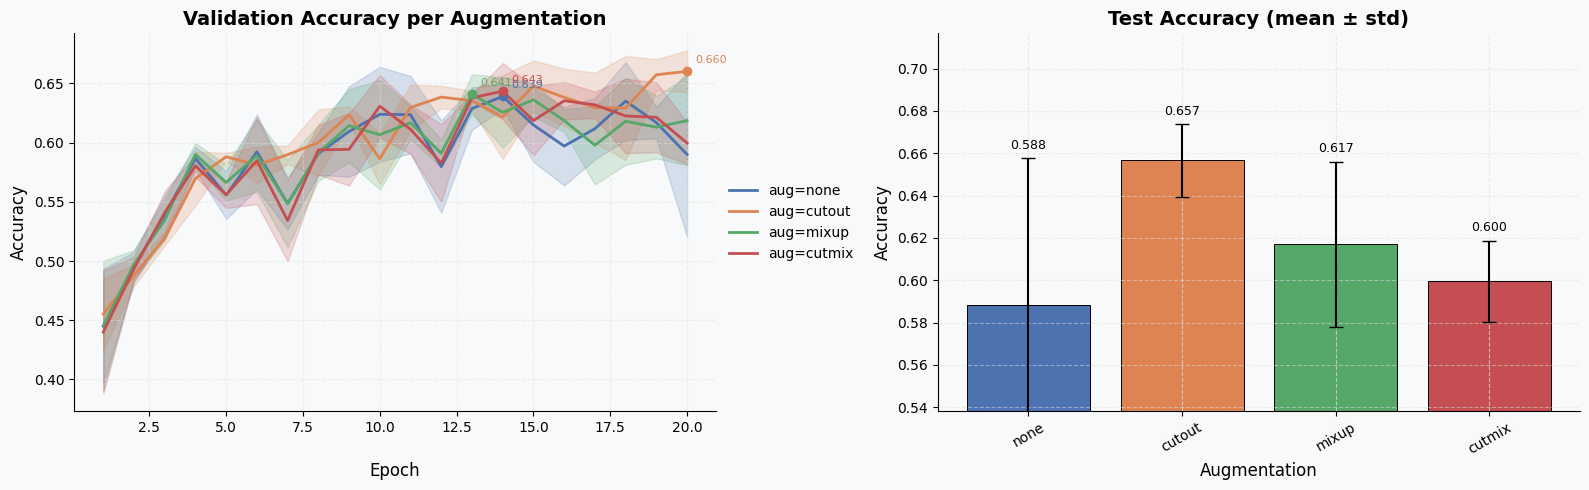

In [12]:
plot_accuracy_comparison(baseline_adv_aug_results, param_name="Augmentation", param_name_short="aug")

In [13]:
save_results(baseline_adv_aug_results, "aug_results_baseline")